In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk

from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet


from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from gensim.models import Word2Vec


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Text Cleaning & Preprocessing

In [3]:
EMOJI_SENTIMENT = {
    "😀": "happy", "😃": "happy", "😄": "happy", "😁": "happy",
    "😆": "happy", "🤣": "happy", "😂": "happy", "🙂": "happy",
    "😊": "happy", "😍": "love", "🥰": "love", "😘": "love",
    "❤️": "love", "💕": "love", "👍": "good", "👏": "good",
    "🔥": "great", "💯": "perfect", "🎉": "celebration",
    "😢": "sad", "😭": "sad", "😞": "sad", "😔": "sad",
    "😠": "angry", "😡": "angry", "🤮": "disgusting",
    "👎": "bad", "💔": "heartbreak", "😒": "annoyed",
    "🙄": "annoyed", "😤": "frustrated",
}

NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor", "cannot",
    "can't", "won't", "don't", "doesn't", "didn't",
    "isn't", "aren't", "wasn't", "weren't",
    "wouldn't", "shouldn't", "couldn't",
    "hasn't", "haven't", "hadn't", "mustn't"
}


STOP_WORDS = set(stopwords.words("english")) - NEGATION_WORDS

lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN


def clean_text(text: str):
    
    text = re.sub(r"<[^>]+>", " ", text)  # 1. Remove HTML

    
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # 2. Remove URLs

    
    for emoji, token in EMOJI_SENTIMENT.items():
        text = text.replace(emoji, f" {token} ")      # 3. Convert emojis → tokens


    text = text.lower()   # 4. Lowercase

    
    text = re.sub(r"n't", " not", text) 
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ll", " will", text)      # 5. Expand common negation contractions
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'s", "", text)

    
    text = re.sub(r"\b(not|no|never)\s+(\w+)", r"\1_\2", text)  # 6. Handle negation (attach next word)

    
    text = re.sub(r"[^a-z_\s]", " ", text)   # 7. Remove non-alpha (keep _ for negation tokens)

    
    text = re.sub(r"\s+", " ", text).strip()  # 8. Normalize spaces

    
    tokens = text.split()  # 9. Tokenize

    
    pos_tags = pos_tag(tokens)   # 10. POS tagging + Lemmatization + Stopword removal

    processed_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
        if word not in STOP_WORDS and len(word) > 1
    ]

    return " ".join(processed_tokens)

df["clean_review"] = df["review"].apply(clean_text)

In [4]:
# Test
sample = "This movie is <b>NOT</b> good 😡! Visited http://bad.com for more."
print("Before:", sample)
print("After :", clean_text(sample))

Before: This movie is <b>NOT</b> good 😡! Visited http://bad.com for more.
After : movie not_good angry visit


In [5]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mention watch oz episode hook rig...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


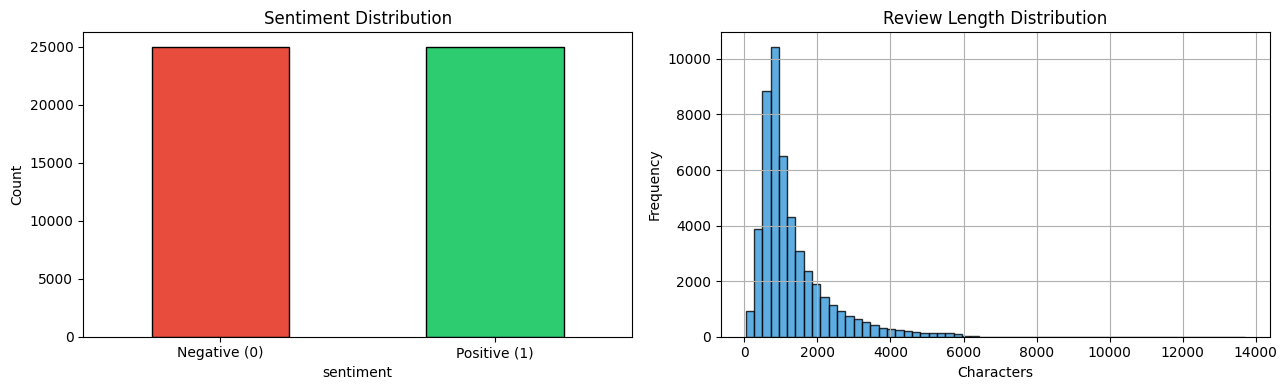

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sentiment distribution
df["sentiment"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c","#2ecc71"], edgecolor="k")
axes[0].set_title("Sentiment Distribution")
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Review length distribution
df["review_len"] = df["review"].str.len()
df["review_len"].hist(bins=60, ax=axes[1], color="#3498db", edgecolor="k", alpha=0.8)
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
df = df.drop_duplicates(subset='clean_review')

df = df[df['clean_review'].str.split().str.len() >= 20]

In [8]:
df.shape

(49256, 4)

In [9]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [10]:
df.head()

,review,sentiment,clean_review,review_len,label
0,One of the other reviewers has mentioned that ...,positive,one reviewer mention watch oz episode hook rig...,1761,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,998,1
2,I thought this was a wonderful way to spend ti...,positive,think wonderful way spend time hot summer week...,926,1
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...,748,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...,1317,1


Sentence Embeddings (BERT) = use BERT as a feature extractor  
Fine-tuning BERT           = train BERT itself on your task

## Feature Engineering – TF-IDF & CountVectorizer

In [11]:
x = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
# TF-IDF (primary)
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer (for comparison / Naïve Bayes)
count_vec = CountVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv  = count_vec.transform(X_test)

print(f"TF-IDF  feature matrix : {X_train_tfidf.shape}")
print(f"CountVec feature matrix: {X_train_cv.shape}")

TF-IDF  feature matrix : (39404, 30000)
CountVec feature matrix: (39404, 30000)


### Model Training & Comparison
### Baseline Models
- Logistic Regression
- Multinomial Naïve Bayes
- Support Vector Machine (LinearSVC)

### Advanced Models
- Random Forest
- Gradient Boosting

In [ ]:
# Logistic Regression (TF-IDF)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# SVM (TF-IDF)
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

# Naive Bayes (CountVectorizer)
nb = MultinomialNB()
nb.fit(X_train_cv, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
models = {
    "Logistic Regression": (lr, X_test_tfidf),
    "SVM": (svm, X_test_tfidf),
    "Naive Bayes": (nb, X_test_cv)
}

for name, (model, X_test) in models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4910
           1       0.90      0.91      0.91      4942

    accuracy                           0.91      9852
   macro avg       0.91      0.91      0.91      9852
weighted avg       0.91      0.91      0.91      9852

Confusion Matrix:
 [[4413  497]
 [ 438 4504]]

SVM
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4910
           1       0.90      0.91      0.91      4942

    accuracy                           0.91      9852
   macro avg       0.91      0.91      0.91      9852
weighted avg       0.91      0.91      0.91      9852

Confusion Matrix:
 [[4431  479]
 [ 455 4487]]

Naive Bayes
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      4910
           1       0.88      0.87      0.87      4942

    accuracy                           0.87      98

In [ ]:
results = []

for name, (model, X_test) in models.items():
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.905095,0.905964
1,SVM,0.905197,0.905733
2,Naive Bayes,0.874949,0.874746


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100)


gb.fit(X_train_tfidf, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
models = {
    "Logistic Regression": (lr, X_test_tfidf),
    "SVM": (svm, X_test_tfidf),
    "Naive Bayes (CountVec)": (nb, X_test_cv),
    "Random Forest": (rf, X_test_tfidf),
    "Gradient Boosting": (gb, X_test_tfidf)
}

results = []

for name, (model, X_test) in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

df_results = pd.DataFrame(results)
print("\n=== Final Comparison ===")
print(df_results.sort_values(by="F1 Score", ascending=False))


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4910
           1       0.90      0.91      0.91      4942

    accuracy                           0.91      9852
   macro avg       0.91      0.91      0.91      9852
weighted avg       0.91      0.91      0.91      9852


SVM
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4910
           1       0.90      0.91      0.91      4942

    accuracy                           0.91      9852
   macro avg       0.91      0.91      0.91      9852
weighted avg       0.91      0.91      0.91      9852


Naive Bayes (CountVec)
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      4910
           1       0.88      0.87      0.87      4942

    accuracy                           0.87      9852
   macro avg       0.87      0.87      0.87      9852
weighted avg       0.87 

In [20]:
df_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.905095,0.905964
1,SVM,0.905197,0.905733
2,Naive Bayes (CountVec),0.874949,0.874746
3,Random Forest,0.858201,0.857725
4,Gradient Boosting,0.814961,0.824357


Logistic Regression and SVLogistic Regression and SVM achieved the best performance (~91% F1 score) due to their ability to handle high-dimensional sparse TF-IDF features efficiently.
Naive Bayes performed slightly worse because it assumes feature independence, which is not valid for natural language (e.g., “not good”).
Random Forest and Gradient Boosting underperformed because tree-based models struggle with sparse high-dimensional data and cannot effectively capture distributed textual features.M achieved the best performance (~91% F1 score) due to their ability to handle high-dimensional sparse TF-IDF features efficiently.
Naive Bayes performed slightly worse because it assumes feature independence, which is not valid for natural language (e.g., “not good”).
Random Forest and Gradient Boosting underperformed because tree-based models struggle with sparse high-dimensional data and cannot effectively capture distributed textual features.

## Feature Engineering – Word2Vec

In [38]:
df2 = pd.read_csv("IMDB Dataset.csv")
df2.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [39]:
import re

EMOJI_SENTIMENT = {
    "😀": "happy","😃":"happy","😄":"happy","😁":"happy",
    "😆":"happy","🤣":"happy","😂":"happy","🙂":"happy",
    "😊":"happy","😍":"love","🥰":"love","😘":"love",
    "❤️":"love","💕":"love","👍":"good","👏":"good",
    "🔥":"great","💯":"perfect","🎉":"celebration",
    "😢":"sad","😭":"sad","😞":"sad","😔":"sad",
    "😠":"angry","😡":"angry","🤮":"disgusting",
    "👎":"bad","💔":"heartbreak","😒":"annoyed",
    "🙄":"annoyed","😤":"frustrated",
}

def clean_text_w2v(text: str):
    text = re.sub(r"<[^>]+>", " ", text)                       # HTML
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)         # URLs

    # emojis → tokens
    for e, tok in EMOJI_SENTIMENT.items():
        text = text.replace(e, f" {tok} ")

    text = text.lower()

    # expand contractions (keep context)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'s", "", text)

    # keep letters only
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text.split()   # tokens

In [40]:
df2["tokens_w2v"] = df2["review"].apply(clean_text_w2v)

In [41]:
# remove duplicates based on raw text or a simple join of tokens
df2 = df2.drop_duplicates(subset="review")

# remove too short
df2 = df2[df2["tokens_w2v"].apply(len) >= 20]

In [42]:
df2.head()

,review,sentiment,tokens_w2v
0,One of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,negative,"[basically, there, a, family, where, a, little..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, mattei, love, in, the, time, of, mone..."


In [7]:
df2.shape

(49554, 3)

In [ ]:
w2v_model = Word2Vec(sentences=df2["tokens_w2v"], vector_size=100, window=5, min_count=5, workers=4)

In [11]:
import numpy as np

def sentence_vector(tokens):
    vecs = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if not vecs:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

X_w2v = np.vstack(df2["tokens_w2v"].apply(sentence_vector))

In [ ]:
y = df2["sentiment"].map({"positive": 1, "negative": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

### Model Training & Comparison
### Baseline Models
- Logistic Regression
- Multinomial Naïve Bayes
- Support Vector Machine (LinearSVC)

### Advanced Models
- Random Forest
- Gradient Boosting

In [ ]:
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
svm_w2v = SVC(kernel="linear")
svm_w2v.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
gb_w2v = GradientBoostingClassifier(n_estimators=100)
gb_w2v.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(models, X_test_dict, y_test):
    results = []

    for name, model in models.items():
        X_test = X_test_dict[name]
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        # ROC-AUC (only if possible)
        try:
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test)[:, 1]
            else:
                y_prob = model.decision_function(X_test)
            
            roc = roc_auc_score(y_test, y_prob)
        except:
            roc = None

        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1,
            "ROC-AUC": roc
        })

    import pandas as pd
    df_results = pd.DataFrame(results)
    return df_results.sort_values(by="F1 Score", ascending=False)

In [ ]:
models_w2v = {
    "LR (W2V)": lr_w2v,
    "SVM (W2V)": svm_w2v,
    "RF (W2V)": rf_w2v,
    "GB (W2V)": gb_w2v
}

for name, model in models_w2v.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


LR (W2V)
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4937
           1       0.85      0.85      0.85      4974

    accuracy                           0.85      9911
   macro avg       0.85      0.85      0.85      9911
weighted avg       0.85      0.85      0.85      9911


SVM (W2V)
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4937
           1       0.85      0.85      0.85      4974

    accuracy                           0.85      9911
   macro avg       0.85      0.85      0.85      9911
weighted avg       0.85      0.85      0.85      9911


RF (W2V)
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      4937
           1       0.81      0.82      0.81      4974

    accuracy                           0.81      9911
   macro avg       0.81      0.81      0.81      9911
weighted avg       0.81      0.81      0.81

In [30]:
models_w2v = {
    "LR (W2V)": lr_w2v,
    "SVM (W2V)": svm_w2v,
    "RF (W2V)": rf_w2v,
    "GB (W2V)": gb_w2v
}

X_test_dict_w2v = {
    "LR (W2V)": X_test,
    "SVM (W2V)": X_test,
    "RF (W2V)": X_test,
    "GB (W2V)": X_test
}

df_results_w2v = evaluate_models(models_w2v, X_test_dict_w2v, y_test)
df_results_w2v

,Model,Accuracy,F1 Score,ROC-AUC
1,SVM (W2V),0.846837,0.847713,0.923228
0,LR (W2V),0.846736,0.847566,0.923057
3,GB (W2V),0.817980,0.819202,0.897846
2,RF (W2V),0.809807,0.811857,0.891058


Word2Vec represents text using dense semantic embeddings, capturing relationships between words. However, when using simple averaging to create sentence vectors, important information such as word order, negation, and word importance is lost. As a result, Word2Vec underperforms compared to TF-IDF in sentiment analysis tasks, where specific keywords and polarity cues are critical.

## Feature Engineering – Glove

In [43]:
import numpy as np

def load_glove(path):
    embeddings = {}
    
    with open(path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector
            
    return embeddings

glove = load_glove("glove.6B.100d.txt")

In [44]:
def sentence_vector_glove(tokens):
    vectors = [glove[w] for w in tokens if w in glove]
    
    if len(vectors) == 0:
        return np.zeros(100)
    
    return np.mean(vectors, axis=0)

In [45]:
X_glove = np.vstack(df2["tokens_w2v"].apply(sentence_vector_glove))

In [46]:
y = df2["sentiment"].map({"positive": 1, "negative": 0})

X_train_g, X_test_g, y_train, y_test = train_test_split(
    X_glove, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
lr_g = LogisticRegression(max_iter=1000).fit(X_train_g, y_train)
svm_g = SVC(kernel="linear").fit(X_train_g, y_train)
rf_g = RandomForestClassifier(n_estimators=100).fit(X_train_g, y_train)
gb_g = GradientBoostingClassifier(n_estimators=100).fit(X_train_g, y_train)

In [49]:
models_glove = {
    "LR (GloVe)": lr_g,
    "SVM (GloVe)": svm_g,
    "RF (GloVe)": rf_g,
    "GB (GloVe)": gb_g
}

X_test_dict_glove = {name: X_test_g for name in models_glove}

df_results_glove = evaluate_models(models_glove, X_test_dict_glove, y_test)
df_results_glove

,Model,Accuracy,F1 Score,ROC-AUC
1,SVM (GloVe),0.799112,0.797189,0.880416
0,LR (GloVe),0.797498,0.796512,0.879815
3,GB (GloVe),0.773888,0.773201,0.855567
2,RF (GloVe),0.770356,0.771898,0.847120


GloVe embeddings performed worse than Word2Vec in this experiment due to domain mismatch and vocabulary coverage limitations. While GloVe embeddings are pretrained on large general corpora, they may not capture domain-specific patterns present in movie reviews. In contrast, Word2Vec was trained directly on the dataset, allowing it to better adapt to the task-specific vocabulary and improve classification performance.

In [ ]:
def load_glove(path):
    embeddings = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector
    return embeddings

glove = load_glove("glove.6B.300d.txt")

In [ ]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    lowercase=False
)

tfidf.fit(df2["tokens_w2v"])
idf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [52]:
def sentence_vector_glove_weighted(tokens):
    vectors = []
    weights = []
    
    for w in tokens:
        if w in glove and w in idf_dict:
            vectors.append(glove[w])
            weights.append(idf_dict[w])
    
    if len(vectors) == 0:
        return np.zeros(300)
    
    vectors = np.array(vectors)
    weights = np.array(weights)
    
    return np.average(vectors, axis=0, weights=weights)

In [53]:
X_glove = np.vstack(df2["tokens_w2v"].apply(sentence_vector_glove_weighted))

In [ ]:
y = df2["sentiment"].map({"positive": 1, "negative": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X_glove, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
svm = SVC(kernel="linear").fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)
gb = GradientBoostingClassifier(n_estimators=100).fit(X_train, y_train)

In [56]:
models = {
    "LR (GloVe weighted)": lr,
    "SVM (GloVe weighted)": svm,
    "RF (GloVe weighted)": rf,
    "GB (GloVe weighted)": gb
}

X_test_dict = {name: X_test for name in models}

df_results = evaluate_models(models, X_test_dict, y_test)
df_results

,Model,Accuracy,F1 Score,ROC-AUC
1,SVM (GloVe weighted),0.818686,0.817136,0.897323
0,LR (GloVe weighted),0.817879,0.816584,0.897175
3,GB (GloVe weighted),0.786500,0.786435,0.870929
2,RF (GloVe weighted),0.772778,0.776232,0.853138


Applying TF-IDF weighting to GloVe embeddings improved performance by emphasizing important words and reducing the influence of less informative terms. However, despite this improvement, GloVe still underperformed compared to TF-IDF due to its inability to capture word order and negation effectively when using averaged sentence representations.

## Feature Engineering – Bert(Sentence Embeddings)